### Imported libraries 

In [1]:
from environment_2 import TrafficEnvironment
from keychain import Keychain as kc
from utilities import confirm_env_variable
from utilities import get_params
import os
from torchrl.envs.libs.pettingzoo import PettingZooWrapper
from torchrl.envs.transforms import TransformedEnv, RewardSum
from torchrl.envs.utils import check_env_specs
from torchrl.envs import TransformedEnv, EnvCreator
from tensordict.nn.distributions import NormalParamExtractor
import torch
from torch import nn
from tensordict.nn import TensorDictModule
from tensordict.nn.distributions import NormalParamExtractor
from torch import nn
from torch.distributions import Categorical

from torchrl.collectors import SyncDataCollector, MultiSyncDataCollector
from torchrl.data.replay_buffers import ReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.objectives.value import GAE
from tqdm import tqdm
# Multi-agent network
from torchrl.modules import MultiAgentMLP, ProbabilisticActor
from torchrl.objectives import ClipPPOLoss, ValueEstimators
import matplotlib.pyplot as plt
import torch
from torch.utils.tensorboard import SummaryWriter
from torchrl.envs import ParallelEnv
%load_ext tensorboard

os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

confirm_env_variable(kc.SUMO_HOME, append="tools")
params = get_params(kc.PARAMS_PATH)

DEBUG:tensorflow:Falling back to TensorFlow client; we recommended you install the Cloud TPU client directly with pip install cloud-tpu-client.
DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7
DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7


[CONFIRMED] Environment variable exists: SUMO_HOME
[SUCCESS] Added module directory: C:\Program Files (x86)\Eclipse\Sumo\tools


### Hyperparameters specification

In [2]:
# Devices
device = (
    torch.device(0)
    if torch.cuda.is_available() and not is_fork
    else torch.device("cpu")
)
vmas_device = device  # The device where the simulator is run (VMAS can run on GPU)

# Sampling
frames_per_batch = 2  # Number of team frames collected per training iteration
n_iters = 6  # Number of sampling and training iterations
total_frames = frames_per_batch * n_iters

# Training
num_epochs = 16  # Number of optimization steps per training iteration
minibatch_size = 16  # Size of the mini-batches in each optimization step
lr = 1e-3  # Learning rate
max_grad_norm = 1.0  # Maximum norm for the gradients

# PPO
clip_epsilon = 0.2  # clip value for PPO loss
gamma = 0.9  # discount factor
lmbda = 0.9  # lambda for generalised advantage estimation
entropy_eps = 1e-4  # coefficient of the entropy term in the PPO loss

### Environment Creation

In [3]:
env = TrafficEnvironment(params[kc.ENVIRONMENT_PARAMETERS], params[kc.SIMULATION_PARAMETERS], params[kc.AGENTS_GENERATION_PARAMETERS], nomachines=True)

INFO:root:[SUCCESS] Generated 4 routes
INFO:root:Simulator is ready to simulate!
INFO:root:Environment initiated!
INFO:root:Free-flow times: {(0, 0): [2.084253701480592, 2.9763105242096835, 1.0603441376550622], (0, 1): [0.7787715086034414, 1.1184673869547819, 0.7676270508203282], (1, 0): [0.7396357391048572, 0.6873687704023294, 0.9195730415996491], (1, 1): [2.0346137303013356, 1.9872287143799205, 2.0234492645150217]}
INFO:root:Free flow times calculated!
INFO:root:There are no machines in this environment!
INFO:root:Free-flow times: {(0, 0): [2.084253701480592, 2.9763105242096835, 1.0603441376550622], (0, 1): [0.7787715086034414, 1.1184673869547819, 0.7676270508203282], (1, 0): [0.7396357391048572, 0.6873687704023294, 0.9195730415996491], (1, 1): [2.0346137303013356, 1.9872287143799205, 2.0234492645150217]}
INFO:root:[SUCCESS] Created agent objects (200)
INFO:root:Machine's observation space is: {} 
INFO:root:Machine's action space is: {}
INFO:root:Minimum travel time is: 0.68736877040

## Humans learning for 300 days

In [4]:
env.start()
observations, infos = env.reset()

for ep in range(1, 10):

    env.reset()
    print(f"Episode {ep}\n\n")
    env.step(machine_joint_action=None)

INFO:root:RESET
INFO:root:New sumo label: 7829
INFO:root:RESET
INFO:root:New sumo label: 1365
INFO:root:STEP
INFO:root:New sumo label: 7878


Episode 1




INFO:root:RESET
INFO:root:New sumo label: 3206
INFO:root:STEP
INFO:root:New sumo label: 6076


Episode 2




INFO:root:RESET
INFO:root:New sumo label: 3359
INFO:root:STEP
INFO:root:New sumo label: 2962


...

Episode 7




INFO:root:RESET
INFO:root:New sumo label: 7532
INFO:root:STEP
INFO:root:New sumo label: 3075


Episode 8




INFO:root:RESET
INFO:root:New sumo label: 4621
INFO:root:STEP
INFO:root:New sumo label: 2557


Episode 9




In [5]:
env.close()

INFO:root:CLOSE


In [6]:
for agent in env.human_agents:
    print("cost table is: ", agent.cost, "\n\n")

cost table is:  [2.03461373 1.98722871 2.02344926] 


cost table is:  [0.73963574 0.68736877 0.91957304] 


cost table is:  [2.03461373 1.98722871 2.02344926] 


cost table is:  [0.73963574 0.68736877 0.91957304] 


cost table is:  [0.77877151 1.11846739 0.76762705] 


cost table is:  [2.0842537  2.97631052 1.06034414] 


cost table is:  [0.73963574 0.68736877 0.91957304] 


cost table is:  [0.77877151 1.11846739 0.76762705] 


cost table is:  [2.03461373 1.98722871 2.02344926] 


cost table is:  [2.03461373 1.98722871 2.02344926] 


cost table is:  [0.73963574 0.68736877 0.91957304] 


cost table is:  [2.0842537  2.97631052 1.06034414] 


cost table is:  [0.77877151 1.11846739 0.76762705] 


cost table is:  [0.73963574 0.68736877 0.91957304] 


cost table is:  [0.77877151 1.11846739 0.76762705] 


cost table is:  [0.77877151 1.11846739 0.76762705] 


cost table is:  [0.77877151 1.11846739 0.76762705] 


cost table is:  [2.0842537  2.97631052 1.06034414] 


cost table is:  [2.0842537  

In [7]:
env.mutation(number_of_machines=1)

INFO:root:Mutation is about to happen!

INFO:root:There were 200 human agents.

INFO:root:Now there are 199 human agents.

INFO:root:Machine's observation space is: {'0': Box(0.0, 200.0, (3,), float32)} 
INFO:root:Machine's action space is: {'0': Discrete(3)}
INFO:root:Agent with id 0 has origin 0 and destination 1 and start time 2823
INFO:root:Minimum travel time is: 0.6873687704023294


self.possible agents after mutation ['0']


### Alignment of our environment with the torchrl environment

In [8]:
env = PettingZooWrapper(
    env=env,
    return_state=True,
    use_mask=True,
    group_map=None, # Use default for parallel
    categorical_actions=True,
)

INFO:root:RESET
INFO:root:New sumo label: 5261


In [9]:
env.reward_keys

[('0', 'reward')]

In [10]:
env

PettingZooWrapper()

In [11]:
env = TransformedEnv(
    env,
    RewardSum(in_keys=env.reward_keys, reset_keys=["_reset"] * len(env.group_map.keys()),),
)

In [12]:
check_env_specs(env)

INFO:root:RESET
INFO:root:New sumo label: 2630
INFO:root:STEP
INFO:root:New sumo label: 4792
INFO:root:Machines are about to learn!
2024-05-14 15:40:16,233 [torchrl][INFO] check_env_specs succeeded!


self.possible_agents ['0']
possible agent is:  0
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
possible agent : 0
origin and destination of the machine agent is:  0 1
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
possible agent : 0
origin and destination of the machine agent is:  0 1
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
possible agent : 0
origin and destination of the machine agent is:  0 1
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
possible agent : 0
origin and 

In [13]:
par_env = ParallelEnv(5, EnvCreator(lambda : env))

INFO:root:RESET
INFO:root:New sumo label: 2210
INFO:root:STEP
INFO:root:New sumo label: 1343
INFO:root:Machines are about to learn!
INFO:root:CLOSE


self.possible_agents ['0']
possible agent is:  0
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
possible agent : 0
origin and destination of the machine agent is:  0 1
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
possible agent : 0
origin and destination of the machine agent is:  0 1
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
possible agent : 0
origin and destination of the machine agent is:  0 1
self.origin is:  [0]
self.destination is:  [1]
self.origin is:  [0]
self.destination is:  [1]
possible agent : 0
origin and 

In [14]:
rollout = par_env.rollout(10)

In [15]:
rollout

TensorDict(
    fields={
        0: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([5, 1, 1]), device=cpu, dtype=torch.int64, is_shared=False),
                done: Tensor(shape=torch.Size([5, 1, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([5, 1, 1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                mask: Tensor(shape=torch.Size([5, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([5, 1, 1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([5, 1, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([5, 1, 1, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([5, 1, 1]),
            device=cpu,
            is_shared=False),
        done: Tensor(shape=torch.Siz

In [16]:
print("action_spec:", par_env.full_action_spec)
print("reward_spec:", par_env.full_reward_spec)
print("done_spec:", par_env.full_done_spec)
print("observation_spec:", par_env.observation_spec)

action_spec: CompositeSpec(
    0: CompositeSpec(
        action: DiscreteTensorSpec(
            shape=torch.Size([5, 1]),
            space=DiscreteBox(n=3),
            device=cpu,
            dtype=torch.int64,
            domain=discrete), device=cpu, shape=torch.Size([5, 1])), device=cpu, shape=torch.Size([5]))
reward_spec: CompositeSpec(
    0: CompositeSpec(
        reward: UnboundedContinuousTensorSpec(
            shape=torch.Size([5, 1, 1]),
            space=None,
            device=cpu,
            dtype=torch.float32,
            domain=continuous), device=cpu, shape=torch.Size([5, 1])), device=cpu, shape=torch.Size([5]))
done_spec: CompositeSpec(
    done: DiscreteTensorSpec(
        shape=torch.Size([5, 1]),
        space=DiscreteBox(n=2),
        device=cpu,
        dtype=torch.bool,
        domain=discrete),
    terminated: DiscreteTensorSpec(
        shape=torch.Size([5, 1]),
        space=DiscreteBox(n=2),
        device=cpu,
        dtype=torch.bool,
        domain

#### Understanding Reward and Action Specs

In the reward and action specs, the "agent" key is present. This means that entries in tensordicts belonging to those specs will be nested within an "agents" tensor dictionary. This grouping organizes all per-agent values.

By accessing the keys for each of these values in tensor dictionaries, we gain insight into which values are per-agent and which ones are shared. This understanding helps us effectively navigate and interpret the reward and action specifications within the environment.


In [17]:
print("action_keys:", par_env.action_keys)
print("reward_keys:", par_env.reward_keys)
print("done_keys:", par_env.done_keys)

action_keys: [('0', 'action')]
reward_keys: [('0', 'reward')]
done_keys: ['done', 'terminated', 'truncated', ('0', 'done'), ('0', 'terminated'), ('0', 'truncated')]


### Creation of the actor/policy neural network

In [18]:
print(par_env.observation_spec["0", "observation"])
print(par_env.action_spec[0])

BoundedTensorSpec(
    shape=torch.Size([5, 1, 3]),
    space=ContinuousBox(
        low=Tensor(shape=torch.Size([5, 1, 3]), device=cpu, dtype=torch.float32, contiguous=True),
        high=Tensor(shape=torch.Size([5, 1, 3]), device=cpu, dtype=torch.float32, contiguous=True)),
    device=cpu,
    dtype=torch.float32,
    domain=continuous)
DiscreteTensorSpec(
    shape=torch.Size([1]),
    space=DiscreteBox(n=3),
    device=cpu,
    dtype=torch.int64,
    domain=discrete)


In [19]:
par_env.action_spec

DiscreteTensorSpec(
    shape=torch.Size([5, 1]),
    space=DiscreteBox(n=3),
    device=cpu,
    dtype=torch.int64,
    domain=discrete)

In [20]:
env.group_map.items()

dict_items([('0', ['0'])])

In [21]:
policy_modules = {}
for group, agents in env.group_map.items():
    share_parameters_policy = True  # Can change this based on the group

    policy_net = MultiAgentMLP(
        n_agent_inputs=env.observation_spec[group, "observation"].shape[
            -1
        ],  # n_obs_per_agent
        n_agent_outputs=env.full_action_spec[group, "action"].shape[
            -1
        ],  # n_actions_per_agents
        n_agents=len(agents),  # Number of agents in the group
        centralised=False,  # the policies are decentralised (i.e., each agent will act from its local observation)
        share_params=share_parameters_policy,
        device=device,
        depth=2,
        num_cells=256,
        activation_class=torch.nn.Tanh,
    )

    # Wrap the neural network in a :class:`~tensordict.nn.TensorDictModule`.
    # This is simply a module that will read the ``in_keys`` from a tensordict, feed them to the
    # neural networks, and write the
    # outputs in-place at the ``out_keys``.

    policy_module = TensorDictModule(
        policy_net,
        in_keys=[(group, "observation")],
        out_keys=[(group, "logits")],
    )  # We just name the input and output that the network will read and write to the input tensordict
    policy_modules[group] = policy_module

In [22]:
policies = {}
for group, _agents in env.group_map.items():
    policy = ProbabilisticActor(
        module=policy_modules[group],
        spec=env.full_action_spec[group, "action"],
        in_keys=[(group, "logits")],
        out_keys=[(group, "action")],
        distribution_class=Categorical,
        return_log_prob=False,
    )
    policies[group] = policy

In [23]:
policies

{'0': ProbabilisticActor(
     module=ModuleList(
       (0): TensorDictModule(
           module=MultiAgentMLP(
             (agent_networks): ModuleList(
               (0): MLP(
                 (0): Linear(in_features=3, out_features=256, bias=True)
                 (1): Tanh()
                 (2): Linear(in_features=256, out_features=256, bias=True)
                 (3): Tanh()
                 (4): Linear(in_features=256, out_features=1, bias=True)
               )
             )
           ),
           device=cpu,
           in_keys=[('0', 'observation')],
           out_keys=[('0', 'logits')])
       (1): SafeProbabilisticModule()
     ),
     device=cpu,
     in_keys=[('0', 'observation')],
     out_keys=[('0', 'logits'), ('0', 'action')])}

In [24]:
print("Running policy:", policy(par_env.reset()[0]))

Running policy: TensorDict(
    fields={
        0: TensorDict(
            fields={
                action: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.int64, is_shared=False),
                done: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                logits: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                mask: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([1]),
            de

### Creation of the critic neural network

In [25]:
critic_modules = {}
for group, agents in env.group_map.items():
    share_parameters_critic = True
    mappo = True  # IPPO if False

    critic_net = MultiAgentMLP(
        n_agent_inputs=env.observation_spec[group, "observation"].shape[-1],
        n_agent_outputs=1,  # 1 value per agent
        n_agents=len(agents),
        centralised=mappo,
        share_params=share_parameters_critic,
        device=device,
        depth=2,
        num_cells=64,
        activation_class=torch.nn.Tanh,
    )

    critic_module = TensorDictModule(
        module=critic_net,
        in_keys=[(group, "observation")],
        out_keys=[(group, "state_value")],
    )
    critic_modules[group] = critic_module

critics = {}
for group, _agents in env.group_map.items():
    critic = TensorDictModule(
        module=critic_modules[group],
        in_keys=[(group, "observation")],
        out_keys=[(group, "state_value")],
    )
    critics[group] = critic

print("Running critic:", critic(par_env.reset()[0]))


Running critic: TensorDict(
    fields={
        0: TensorDict(
            fields={
                done: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                episode_reward: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                mask: Tensor(shape=torch.Size([1]), device=cpu, dtype=torch.bool, is_shared=False),
                observation: Tensor(shape=torch.Size([1, 3]), device=cpu, dtype=torch.float32, is_shared=False),
                state_value: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.float32, is_shared=False),
                terminated: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False),
                truncated: Tensor(shape=torch.Size([1, 1]), device=cpu, dtype=torch.bool, is_shared=False)},
            batch_size=torch.Size([1]),
            device=cpu,
            is_shared=False),
        done: Tensor(shape=torch.Size([1]), device=cpu, dt

### Collector

> At every learning iteration we have a sampling and a training phase. In the sampling phase of iteration t, rollouts are collected from agent's interactions in the environment using the currect policies π_{t}. So, in the training phase the same policy is used to take the different samples.

![](images/On-policy-rollouts.png)

#### Understanding Training Parameters

- `n_iters`: This variable determines the number of iterations for the training loop. In other words, it specifies how many times the policy will be updated during training.

- `frames_per_batch`: This parameter indicates the amount of data that will be sampled using the current policy before updating the model. It represents the number of frames or observations collected from the environment within each training batch. These frames serve as the basis for learning in the model.


In [26]:
collector = MultiSyncDataCollector(
    [par_env],
    policy,
    device=device,
    storing_device=device,
    frames_per_batch=frames_per_batch,
    reset_at_each_iter=False,
    total_frames=total_frames,
)

### Replay Buffer

In [27]:
replay_buffers = {}
for group, _agents in env.group_map.items():
    replay_buffers[group] = ReplayBuffer(
        storage=LazyTensorStorage(
            frames_per_batch, device=device
        ),  # We store the frames_per_batch collected at each iteration
        sampler=SamplerWithoutReplacement(),
        batch_size=minibatch_size,  # We will sample minibatches of this size
    )

### PPO loss function

In [28]:
loss_modules = {}
for group, _agents in env.group_map.items():
    loss_module = ClipPPOLoss(
        actor_network=policies[group],
        critic_network=critics[group],
        clip_epsilon=clip_epsilon,
        entropy_coef=entropy_eps,
        normalize_advantage=False,  # Important to avoid normalizing across the agent dimension
    )
    loss_module.set_keys(  # We have to tell the loss where to find the keys
        reward=(group, "reward"),  # Use the specific reward key for the current group
        action=(group, "action"),  # Assuming action keys for both agents are in the same group
        sample_log_prob=(group, "sample_log_prob"),
        value=(group, "state_value"),
        # These last 2 keys will be expanded to match the reward shape
        done=(group, "done"),
        terminated=(group, "terminated"),
    )

    loss_module.make_value_estimator(
        ValueEstimators.GAE, gamma=gamma, lmbda=lmbda
    )  # We build GAE
    GAE = loss_module.value_estimator

    optimizer = torch.optim.Adam(loss_module.parameters(), lr)
    loss_modules[group] = (loss_module, optimizer)

# Access loss module for the first group for example
group = next(iter(env.group_map))
loss_module, optimizer = loss_modules[group]


In [29]:
writer = SummaryWriter('/runs')

### Training Loop Overview

We query tensordict data from our collector object. The data collector serves as an intermediary between the policy and the environment.

- The data collector iterates the policy within the environment, executing steps in the environment, computing actions based on the policy's output, and repeating this process iteratively.

- It consolidates the collected data and presents it to us as a tensor dictionary. This tensor dictionary is structured in a way that is meaningful and relevant for our specific use case.

The inside of the loop involves the processing of the data we gathered from the collector. This process entails:

- Subsetting the collected data.
- Running the environment for a specified number of days (e.g., 6 days).
- Training the policy based on the information collected from the environment.

In essence, during the training loop, we simulate the environment for a certain duration(6 days in our case - using the same policy) and then use the collected data to train the policy. This process represents the learning phase for the agents, depicted as the "Sampling" part of the graph.


In [30]:
pbar = tqdm(total=n_iters, desc="episode_reward_mean = 0")

episode_reward_mean_list = []
for tensordict_data in collector:
    print("inside the loop\n")
    # Update done and terminated for both agents
    for group, _agents in env.group_map.items():
        tensordict_data.set(
            ("next", group, "done"),
            tensordict_data.get(("next", "done"))
            .unsqueeze(-1)
            .expand(tensordict_data.get_item_shape(("next", group, "reward"))),  # Adjust index to start from 0
        )
        tensordict_data.set(
            ("next", group, "terminated"),
            tensordict_data.get(("next", "terminated"))
            .unsqueeze(-1)
            .expand(tensordict_data.get_item_shape(("next", group, "reward"))),  # Adjust index to start from 0
        )


    print("after tensordict data\n")

    # Compute GAE for both agents
    with torch.no_grad():
        for group, _agents in env.group_map.items():
            GAE(
                tensordict_data,
                params=loss_modules[group][0].critic_network_params,
                target_params=loss_modules[group][0].target_critic_network_params,
            )

    # Flatten and extend data for both agents
    for group, _agents in env.group_map.items():
        data_view = tensordict_data.reshape(-1)  # Flatten the batch size to shuffle data
        replay_buffers[group].extend(data_view)

    print("[INFO] Before the learning loop")
    for epoch in range(num_epochs):
        for group, _agents in env.group_map.items():
            for _ in range(frames_per_batch // minibatch_size):
                subdata = replay_buffers[group].sample()
                loss_vals = loss_modules[group](subdata)

                loss_value = (
                    loss_vals["loss_objective"]
                    + loss_vals["loss_critic"]
                    + loss_vals["loss_entropy"]
                )

                loss_value.backward()

                torch.nn.utils.clip_grad_norm_(
                    loss_modules[group].parameters(), max_grad_norm
                )  # Optional

                optimizers[group].step()
                optimizers[group].zero_grad()
                print(f"Loss/train for agent {group}:", loss_value, epoch)
                writer.add_scalar(f"Loss/train_agent_{group}", loss_value, global_step=epoch)

    # Update policy weights for both agents
    #for group, _agents in env.group_map.items():
    collector.update_policy_weights_()


    print("[INFO] Before the logging")
    

    for group, _agents in env.group_map.items():
        done = tensordict_data.get(("next", group, "done"))  # Assuming done status is the same for both agents
        print("group is: ", group, "done is: ", done)

        episode_reward_mean = (
            tensordict_data.get(("next", group, "reward"))[done].mean().item()
        )

        print("episode_reward_mean is: ", episode_reward_mean)
        episode_reward_mean_list.append(episode_reward_mean)  # Store the episode reward mean for the corresponding agent
        print("episode_reward_mean_list is: ", episode_reward_mean_list)
        pbar.set_description(f"episode_reward_mean_agent_{group} = {episode_reward_mean}", refresh=False)

    pbar.update()

episode_reward_mean_agent_0 = -1.1966667175292969:  17%|█▋        | 1/6 [00:06<00:32,  6.45s/it]

inside the loop

after tensordict data

[INFO] Before the learning loop
[INFO] Before the logging
group is:  0 done is:  tensor([[[[True]]],


        [[[True]]],


        [[[True]]],


        [[[True]]],


        [[[True]]]])
episode_reward_mean is:  -1.1966667175292969
episode_reward_mean_list is:  [-1.1966667175292969]


episode_reward_mean_agent_0 = -1.2000000476837158:  33%|███▎      | 2/6 [00:13<00:26,  6.64s/it]

inside the loop

after tensordict data

[INFO] Before the learning loop
[INFO] Before the logging
group is:  0 done is:  tensor([[[[True]]],


        [[[True]]],


        [[[True]]],


        [[[True]]],


        [[[True]]]])
episode_reward_mean is:  -1.2000000476837158
episode_reward_mean_list is:  [-1.1966667175292969, -1.2000000476837158]


episode_reward_mean_agent_0 = -1.1966667175292969:  50%|█████     | 3/6 [00:19<00:19,  6.51s/it]

inside the loop

after tensordict data

[INFO] Before the learning loop
[INFO] Before the logging
group is:  0 done is:  tensor([[[[True]]],


        [[[True]]],


        [[[True]]],


        [[[True]]],


        [[[True]]]])
episode_reward_mean is:  -1.1966667175292969
episode_reward_mean_list is:  [-1.1966667175292969, -1.2000000476837158, -1.1966667175292969]


In [ ]:
for group, _agent, in env.group_map.items():
    print(episode_reward_mean_list[group])

[-3.611792802810669, -3.5836899280548096, -3.5875937938690186]
[-3.611792802810669, -3.5836899280548096, -3.5875937938690186]


DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=12.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\Anastasia\\anaconda3\\envs\\torchrl\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSerif-Bold.ttf', name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\Anastasia\\anaconda3\\envs\\torchrl\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXSizFiveSymReg.ttf', name='STIXSizeFiveSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='c:\\Users\\Anastasia\\anaconda3\\envs\\torchrl\\Lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\STIXGeneralItalic.ttf', name='STIXGeneral', style='italic', variant='normal', weight=400, stretch='norm

group is:  1
group is:  2


DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\BRLNSB.TTF', name='Berlin Sans FB', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\georgiaz.ttf', name='Georgia', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\HARLOWSI.TTF', name='Harlow Solid Italic', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\ITCEDSCR.TTF', name='Edwardian Script ITC', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='C:\\Windows\\Fonts\\ebrima.ttf', name='Ebrima', style='normal', variant='normal', weight=

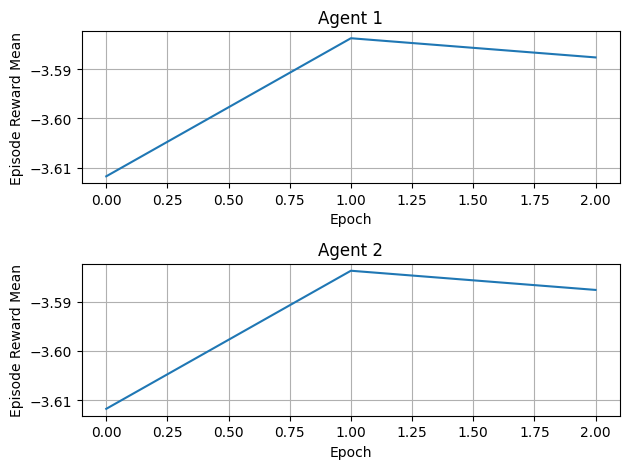

In [ ]:
fig, axs = plt.subplots(2, 1)

# Plotting
for (group_name, group_key), ax in zip(env.group_map.items(), axs):
    print("group is: ", group_name)
    ax.plot(episode_reward_mean_list[group_name])
    ax.set_title(f"Agent {group_name}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Episode Reward Mean")
    ax.grid(True)

plt.tight_layout()
plt.show()